# 🔢 From text to numbers

**Day 1 afternoon — Introduction to Machine Learning for Text Analysis with Python**

<img src="https://raw.githubusercontent.com/Rptkiddle/gesis-machine-learning-2026/main/images/01_preprocessing.png" alt="Preprocessing brick" style="max-width: 130px;"> <img src="https://raw.githubusercontent.com/Rptkiddle/gesis-machine-learning-2026/main/images/02_tokenization.png" alt="Tokenization brick" style="max-width: 130px;"> <img src="https://raw.githubusercontent.com/Rptkiddle/gesis-machine-learning-2026/main/images/03_vectorization.png" alt="Vectorization brick" style="max-width: 130px;">

A computer cannot read words, but it can do maths on numbers. So the first question is always: how do we convert text into numbers, and what do we lose (or gain) in the process? Today we'll explore this question.

This notebook walks through three ways to do that:

1. **Dictionary** — count how often words from a list you wrote appear.
2. **Bag-of-words** — count how often *every* word in the corpus appears.
3. **Embeddings** — let a pre-trained model place each sentence in a "meaning space."

> Each approach 'sees' text differently. By the end of this notebook you will understand what each one can and cannot do.

---

## 1. The corpus

We use a small corpus built for this notebook. It is composed of 45 short sentences organised around five words that have more than one meaning (*bank*, *cool*, *trunk*, *duck*, *figure*).

For each word the corpus contains:

- one **ambiguous** sentence, where you cannot tell which sense is meant ("I saw her duck.");
- four sentences for **sense A** (the duck as an animal);
- four sentences for **sense B** (to duck as a movement).

### 🎯 Two test cases

We will use these throughout the notebook to judge each representation:

- **Test 1 — same meaning, different words.** "Her job is really interesting and fun." and "She works in a creative field and loves it." mean nearly the same thing, but share almost no words.
- **Test 2 — same word, different meaning.** "I'm heading to the bank to withdraw some cash." and "I enjoy walking along the river bank." share the word *bank*, but mean very different things.

A good representation should give high similarity for Test 1 and low similarity for Test 2.

In [1]:
# --- Import libraries ---
import numpy as np # for numerical operations
import pandas as pd # for dataframes (i.e. tables)
import matplotlib.pyplot as plt #for basic plotting
import seaborn as sns #for prettier plotting

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer  # turns text into word-count matrices ('Document-Term Matrices')
from sklearn.metrics.pairwise import cosine_similarity       # measures how similar two vectors are (in semantic space)
from nltk.stem.snowball import SnowballStemmer               # reduces words to their stem (e.g. "running" → "run")

from sklearn.decomposition import PCA                    # compresses many dimensions to 2 for our human eyes (plotting)
from sentence_transformers import SentenceTransformer    # loads pre-trained embedding models (we'll use one of these)
import torch                                             # needed to check GPU availability (for faster computation)

SEED = 42  # fixed random seed so results are identical on every run

In [2]:
# --- The corpus ---
# Each entry is (ambiguous word, sense label, sentence).
corpus_data = [
    # bank: financial institution (money) vs side of a river (river)
    ("bank", "ambiguous", "I'm going down to the bank."),
    ("bank", "money", "I need to visit the bank today."),
    ("bank", "money", "I'm heading to the bank to withdraw some cash."),
    ("bank", "money", "The bank is where I'm off to."),
    ("bank", "money", "I have an appointment at the bank."),
    ("bank", "river", "Let's spend the day by the river bank."),
    ("bank", "river", "The river bank is a peaceful place to relax."),
    ("bank", "river", "I enjoy walking along the river bank."),
    ("bank", "river", "We can have a picnic by the river bank."),
    # cool: interesting/great (nice) vs low temperature (cold)
    ("cool", "ambiguous", "She has a cool job."),
    ("cool", "nice", "Her job is really interesting and fun."),
    ("cool", "nice", "She works in a creative field and loves it."),
    ("cool", "nice", "That job of hers is so unique."),
    ("cool", "nice", "She's lucky to have such a cool profession."),
    ("cool", "cold", "Her workplace is always chilly."),
    ("cool", "cold", "She works in a refrigerated environment."),
    ("cool", "cold", "The temperature in her office is freezing."),
    ("cool", "cold", "She needs to bundle up for her job."),
    # trunk: car storage (car) vs tree trunk (tree)
    ("trunk", "ambiguous", "You need to check the trunk."),
    ("trunk", "car", "Don't forget to look in the trunk of the car."),
    ("trunk", "car", "There might be something important in the trunk."),
    ("trunk", "car", "Make sure to verify the contents of the trunk."),
    ("trunk", "car", "The trunk needs to be inspected for any damage."),
    ("trunk", "tree", "Take a look at the tree trunk for any damage."),
    ("trunk", "tree", "The trunk of the old tree might have some interesting carvings."),
    ("trunk", "tree", "Check if the tree trunk needs to be treated for pests."),
    ("trunk", "tree", "See if there are any unique patterns or textures on the tree trunk."),
    # duck: the bird (animal) vs the movement (verb)
    ("duck", "ambiguous", "I saw her duck."),
    ("duck", "animal", "Her duck was waddling in the park."),
    ("duck", "animal", "The duck she owns is so cute."),
    ("duck", "animal", "I spotted her duck by the pond."),
    ("duck", "animal", "Her duck was quacking loudly."),
    ("duck", "verb", "She ducked to avoid the flying object."),
    ("duck", "verb", "Her quick ducking saved her from the falling branch."),
    ("duck", "verb", "I noticed her sudden ducking movement."),
    ("duck", "verb", "She ducked and dodged the incoming ball."),
    # figure: body shape (body) vs a number (number)
    ("figure", "ambiguous", "She has a great figure."),
    ("figure", "body", "Her body shape is very flattering."),
    ("figure", "body", "She carries herself with grace and confidence."),
    ("figure", "body", "Her figure is well-proportioned and attractive."),
    ("figure", "body", "She knows how to dress to highlight her figure."),
    ("figure", "number", "The numerical figure she presented was impressive."),
    ("figure", "number", "Her calculations yielded a significant figure."),
    ("figure", "number", "The data supports a substantial figure."),
    ("figure", "number", "The figure she quoted was accurate and reliable."),
]

df = pd.DataFrame(corpus_data, columns=["word", "sense", "sentence"])
df["label"] = df["word"] + "-" + df["sense"]  # combined label for plot axes (e.g. "bank-money")

print(f"Number of sentences: {len(df)}")
df

Number of sentences: 45


,word,sense,sentence,label
0,bank,ambiguous,I'm going down to the bank.,bank-ambiguous
1,bank,money,I need to visit the bank today.,bank-money
2,bank,money,I'm heading to the bank to withdraw some cash.,bank-money
3,bank,money,The bank is where I'm off to.,bank-money
4,bank,money,I have an appointment at the bank.,bank-money
5,bank,river,Let's spend the day by the river bank.,bank-river
6,bank,river,The river bank is a peaceful place to relax.,bank-river
7,bank,river,I enjoy walking along the river bank.,bank-river
8,bank,river,We can have a picnic by the river bank.,bank-river
9,cool,ambiguous,She has a cool job.,cool-ambiguous


---

## 2. 📋 Representation 1: a dictionary

The simplest approach. You write a list of words for the concept you want to measure, then count how often those words appear in each text. That count *is* the representation. All other 'features' of the text are ignored. 

This is a **deductive** method: you decide in advance what matters. If your word list is good, the results are good. If the list misses important words, this measurement method misses them too.

Let's try it on the nine *bank* sentences. We write two small dictionaries — one for the money sense, one for the river sense — and count matches.

In [3]:
# --- Two small dictionaries ---
money_words = ["bank", "cash", "withdraw", "money", "appointment"]
nature_words = ["river", "picnic", "relax", "peaceful"]

def count_hits(sentence, wordlist):
    """Count how many words from the wordlist appear in the sentence."""
    hits = 0                              # initialize counter at zero.
    for word in sentence.lower().split(): # iterate over each word in the sentence (lowercased and split into a list of words)
        word = word.strip(".,!?'")        # remove punctuation stuck to the word 
        if word in wordlist:              # if the word is in the wordlist
            hits = hits + 1               # ...increment the counter by one
    return hits                           # and return the final count of hits.

# Apply both dictionaries to the nine bank sentences
bank_df = df[df["word"] == "bank"].copy()
bank_df["money_hits"] = [count_hits(s, money_words) for s in bank_df["sentence"]]
bank_df["nature_hits"] = [count_hits(s, nature_words) for s in bank_df["sentence"]]

bank_df[["sense", "sentence", "money_hits", "nature_hits"]]

,sense,sentence,money_hits,nature_hits
0,ambiguous,I'm going down to the bank.,1,0
1,money,I need to visit the bank today.,1,0
2,money,I'm heading to the bank to withdraw some cash.,3,0
3,money,The bank is where I'm off to.,1,0
4,money,I have an appointment at the bank.,2,0
5,river,Let's spend the day by the river bank.,1,1
6,river,The river bank is a peaceful place to relax.,1,3
7,river,I enjoy walking along the river bank.,1,1
8,river,We can have a picnic by the river bank.,1,2


Look at the river sentences. Every one of them scores at least one hit on the **money** dictionary, because they all contain the word *bank*, and *bank* is on our money list. 

Three lessons:

- **You get out what you put in.** The word lists *are* essentially the method. 
- **Matching is exact.** *Withdraw* matches, *withdrew* does not — unless you add it to the list.
- **Every word is treated as having one fixed meaning.** Ambiguity (as above) breaks this assumption.

Dictionaries still have a limited place in today's NLP. When a concept has a stable, unambiguous vocabulary (like the World Uncertainty Index from the slides), a dictionary is transparent, fast, and easy to explain. However, as the next steps will elaborate, we can create much richer semantic representations of texts...

---

## 3. 🧺 Representation 2: bag-of-words

<img src="https://raw.githubusercontent.com/Rptkiddle/gesis-machine-learning-2026/main/images/01_preprocessing.png" alt="Preprocessing brick" style="max-width: 130px;"> <img src="https://raw.githubusercontent.com/Rptkiddle/gesis-machine-learning-2026/main/images/02_tokenization.png" alt="Tokenization brick" style="max-width: 130px;"> <img src="https://raw.githubusercontent.com/Rptkiddle/gesis-machine-learning-2026/main/images/03_vectorization.png" alt="Vectorization brick" style="max-width: 130px;">

Instead of choosing which words to count, we now count **every** word. Each sentence becomes a row of numbers with one column per word in the vocabulary. The value in each cell is how many times that word appears in that sentence. Word order is thrown away — hence "bag" of words.

Raw text is messy. "The" and "the" look like different words to a computer. So counting is usually combined with **preprocessing** steps that clean the text first. We will build the representation four times, adding one step each time, so you can see what each step does.


### Step 0: tokenization

Before anything can be counted, the text has to be split into units — **tokens**. This happens before every other step, which is why we call it step 0.

The simplest tokenizer splits on spaces. That works, but it leaves punctuation stuck to words and doesn't handle contractions. Compare it with a proper tokenizer from the NLTK library:

In [4]:
# --- Two ways to split a sentence into tokens ---
from nltk.tokenize import TreebankWordTokenizer

example = "I'm heading to the bank to withdraw some cash."

# Simple: split on spaces
print("split():  ", example.split())

# Proper tokenizer: separates punctuation and splits contractions
print("Treebank: ", TreebankWordTokenizer().tokenize(example))

split():   ["I'm", 'heading', 'to', 'the', 'bank', 'to', 'withdraw', 'some', 'cash.']
Treebank:  ['I', "'m", 'heading', 'to', 'the', 'bank', 'to', 'withdraw', 'some', 'cash', '.']


Look at the differences: `split()` leaves `"cash."` as one token (with the full stop attached) and keeps `"I'm"` together. The Treebank tokenizer separates the punctuation and splits `"I'm"` into `I` + `'m`.

> 💡 The vectorizer we use below applies its own tokenizer internally, so we will not tokenize by hand.

### Step 1: no preprocessing

In [8]:
# --- Count words with no preprocessing ---
vec_raw = CountVectorizer(lowercase=False)        # lowercase=False: keep capitalisation as-is
X_raw = vec_raw.fit_transform(df["sentence"])     # build the vocabulary and count words
vocab_raw = vec_raw.get_feature_names_out()       # the vocabulary (= the column names)

print(f"Vocabulary size: {len(vocab_raw)}")
print(f"'The' in vocabulary: {'The' in vocab_raw}")
print(f"'the' in vocabulary: {'the' in vocab_raw}")
print(f"'Her' in vocabulary: {'Her' in vocab_raw}")
print(f"'her' in vocabulary: {'her' in vocab_raw}")

Vocabulary size: 162
'The' in vocabulary: True
'the' in vocabulary: True
'Her' in vocabulary: True
'her' in vocabulary: True


Hmm. "The" and "the" are counted as two separate words — they get two separate columns. The computer compares characters, and uppercase "T" is not the same as lowercase "t". The same goes for "Her" and "her". In a bag-of-words representation, these are treated as separate words or 'features' in the vocabulary. We probably don't want that. 

### Step 2: lowercasing

In [6]:
# --- Lowercase everything before counting ---
vec_lower = CountVectorizer()                       # lowercase=True is the default
X_lower = vec_lower.fit_transform(df["sentence"])
vocab_lower = vec_lower.get_feature_names_out()

print(f"Vocabulary size before: {len(vocab_raw)}")
print(f"Vocabulary size after lowercasing: {len(vocab_lower)}")
print(f"\nExamples: 'The' and 'the' merged into one column; 'Her' and 'her' merged into one column.")

Vocabulary size before: 162
Vocabulary size after lowercasing: 157

Examples: 'The' and 'the' merged into one column; 'Her' and 'her' merged into one column.


The vocabulary shrank because capitalised and lowercase versions now share a single column.

### Step 3: stopword removal

Words like *the*, *to*, *she*, and *is* appear in almost every sentence. They carry little information for distinguishing topics, and they drown out the words that do. A **stopword list** removes them before counting.

In [9]:
# --- Remove English stopwords ---
vec_stop = CountVectorizer(stop_words="english")    # use scikit-learn's built-in English stopword list
X_stop = vec_stop.fit_transform(df["sentence"])
vocab_stop = vec_stop.get_feature_names_out()

print(f"Vocabulary size after lowercasing: {len(vocab_lower)}")
print(f"Vocabulary size after stopword removal: {len(vocab_stop)}")

# What survives stopword removal?
example = "I'm going to the bank."
remaining = vec_stop.inverse_transform(vec_stop.transform([example]))[0]
print(f"\n'{example}'  ->  {sorted(remaining)}")

Vocabulary size after lowercasing: 157
Vocabulary size after stopword removal: 110

'I'm going to the bank.'  ->  [np.str_('bank'), np.str_('going')]


Most of the sentence is gone, but nothing important was lost. The counting now focuses on content words.

### Step 4: stemming

The corpus contains *duck*, *ducked*, and *ducking*. These are all forms of the same word, but the vectoriser treats them as three separate columns. A **stemmer** cuts words back to a shared root so that different forms merge into one column.

(A more careful alternative is **lemmatisation**, which uses grammar rules to find the dictionary form — see the slides.)

In [10]:
# --- Stem every word, then count ---
stemmer = SnowballStemmer("english")

def stem_sentence(sentence):
    """Cut every word in the sentence back to its stem."""
    words = sentence.lower().split()
    words = [w.strip(".,!?'") for w in words]
    stems = [stemmer.stem(w) for w in words]
    return " ".join(stems)

# See what stemming does to "duck", "ducked", and "ducking"
for s in ["I saw her duck.", "She ducked to avoid the flying object.", "I noticed her sudden ducking movement."]:
    print(f"{s:<45} ->  {stem_sentence(s)}")

# Build the final bag-of-words matrix: stemmed + stopwords removed
df["stemmed"] = [stem_sentence(s) for s in df["sentence"]]
vec_final = CountVectorizer(stop_words="english")
X_bow = vec_final.fit_transform(df["stemmed"])
vocab_final = vec_final.get_feature_names_out()

print(f"\nVocabulary size after stemming: {len(vocab_final)}")

I saw her duck.                               ->  i saw her duck
She ducked to avoid the flying object.        ->  she duck to avoid the fli object
I noticed her sudden ducking movement.        ->  i notic her sudden duck movement

Vocabulary size after stemming: 108


Notice that stemming produces stems, not always real words — *figure* became *figur*. Each step made the vocabulary smaller and cleaner:

| Step | What it does |
|---|---|
| Nothing | "The" and "the" are separate columns |
| Lowercasing | capitalised and lowercase forms merge |
| Stopword removal | common function words are dropped |
| Stemming | different word forms merge into one stem |

> ⚠️ **Preprocessing choices are research decisions.** Each step changes the representation, and therefore the results. Always report what preprocessing you used.

### What the matrix looks like

Below is the actual representation: one row per sentence, one column per word stem. Each cell holds a count.

> 💡 By default the vectorizer counts single words (*unigrams*). It can also count word pairs (*bigrams*): `CountVectorizer(ngram_range=(1, 2))`. Then *river bank* becomes a feature of its own — one way to give a bag-of-words model a little bit of context.

In [11]:
# --- Show a piece of the document-term matrix ---
# Show selected columns for the first 9 sentences (the bank block)
bow_df = pd.DataFrame(X_bow.toarray(), columns=vocab_final)

show_columns = ["bank", "river", "cash", "withdraw", "picnic", "job", "duck", "tree", "figur"]
bow_df[show_columns].head(9)

,bank,river,cash,withdraw,picnic,job,duck,tree,figur
0,1,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0
2,1,0,1,1,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0
5,1,1,0,0,0,0,0,0,0
6,1,1,0,0,0,0,0,0,0
7,1,1,0,0,0,0,0,0,0
8,1,1,0,0,1,0,0,0,0


In [12]:
# --- How empty is this matrix? ---
total_cells = X_bow.shape[0] * X_bow.shape[1]
filled_cells = X_bow.nnz                            # cells that are not zero
print(f"Matrix size: {X_bow.shape[0]} sentences × {X_bow.shape[1]} word stems = {total_cells} cells")
print(f"Cells that are not zero: {filled_cells} ({filled_cells / total_cells:.1%})")

Matrix size: 45 sentences × 108 word stems = 4860 cells
Cells that are not zero: 159 (3.3%)


Most sentences don't contain most words, so the vast majority of cells are zero. This emptiness is called **sparsity**, and it grows fast with real corpora where the vocabulary has tens of thousands of words.

### From counts to weights: TF-IDF

There is one refinement to our bag-of-words model left to introduce. Raw counts treat every word as equally important, but some words are more informative than others. Within the nine *bank* sentences, the word *bank* appears everywhere, so it does not help us tell those sentences apart. *Cash* and *picnic* appear in one sentence each — these terms are more discriminative. 

**TF-IDF** (term frequency, inverse document frequency) weights more discriminative terms more heavily, and reduces the weight of more common words. Let's apply it to the same sentences and columns as above.

In [13]:
# --- The same matrix, TF-IDF weighted ---
tfidf_vec = TfidfVectorizer(stop_words="english")     # same setup as before, but weighted
X_tfidf = tfidf_vec.fit_transform(df["stemmed"])

# Show the same rows and columns as the count matrix above
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vec.get_feature_names_out())
tfidf_df[show_columns].head(9).round(2)

,bank,river,cash,withdraw,picnic,job,duck,tree,figur
0,1.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0
1,0.36,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0
2,0.33,0.00,0.54,0.54,0.00,0.0,0.0,0.0,0.0
3,1.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0
4,0.52,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0
5,0.31,0.39,0.00,0.00,0.00,0.0,0.0,0.0,0.0
6,0.31,0.39,0.00,0.00,0.00,0.0,0.0,0.0,0.0
7,0.35,0.45,0.00,0.00,0.00,0.0,0.0,0.0,0.0
8,0.43,0.55,0.00,0.00,0.71,0.0,0.0,0.0,0.0


The counts became continuous weights. Look at the sentence "I'm heading to the bank to withdraw some cash." (row 2). All three content words appear exactly once, but *bank* scores 0.33 while *cash* and *withdraw* score 0.54. Why? *Bank* appears in all nine of these sentences, so it is weighted down. *Cash* appears in only one, so it is weighted up. The most informative words now carry the biggest numbers.

> 💡 Why is *bank* exactly 1.00 in some rows? Those sentences kept only one word after preprocessing, and each row is rescaled to a fixed total length. So compare weights *within* a row, not across rows.


### What does bag of words think is similar?

Now the key question. We compute the **cosine similarity** between every pair of sentences. Cosine similarity gives a number between 0 (nothing in common) and 1 (identical word distribution). We plot all pairs as a heatmap.

The sentences are ordered by word and sense. If the representation captures meaning, we should see dark blocks along the diagonal for each sense group.

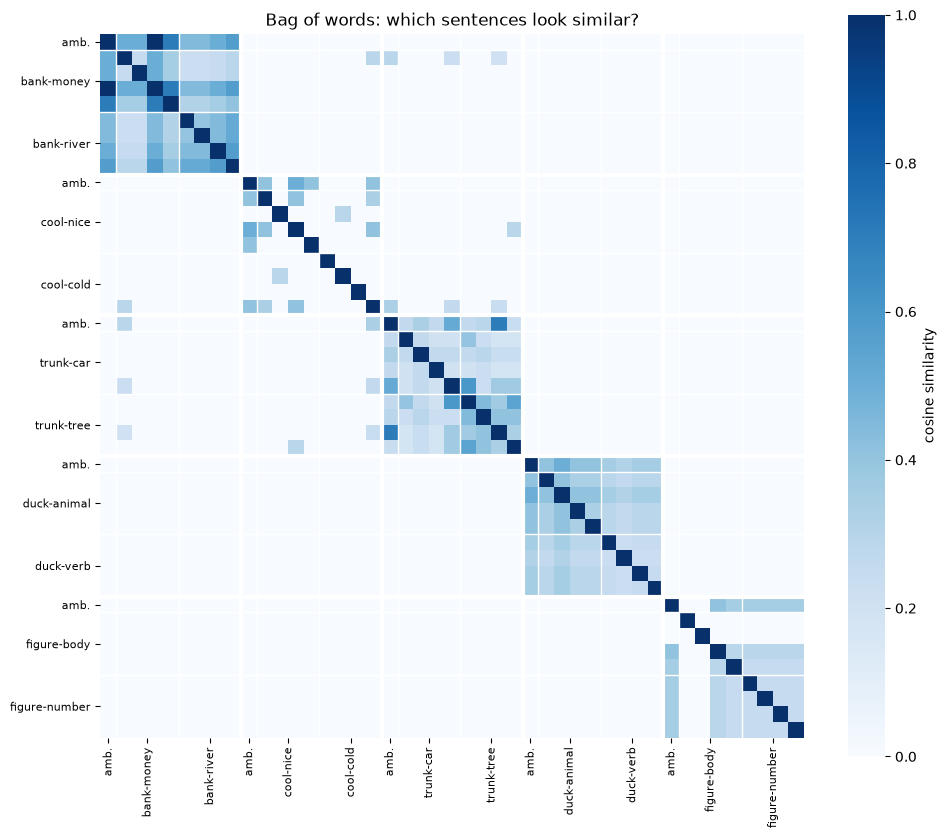

In [14]:
# --- Similarity heatmap for bag of words ---

def plot_similarity(sim_matrix, title):
    """Heatmap of sentence-to-sentence similarity, with the word/sense groups marked."""
    plt.figure(figsize=(10, 8.5))
    ax = sns.heatmap(sim_matrix, cmap="Blues", vmin=0, vmax=1, square=True,
                     xticklabels=False, yticklabels=False,
                     cbar_kws={"label": "cosine similarity"})

    # thick white lines between the five word blocks, thin ones between sense groups
    for pos in range(9, 45, 9):
        ax.axhline(pos, color="white", linewidth=3)
        ax.axvline(pos, color="white", linewidth=3)
    for start in range(0, 45, 9):
        for offset in (1, 5):   # each block: 1 ambiguous sentence, 4 sense A, 4 sense B
            ax.axhline(start + offset, color="white", linewidth=1)
            ax.axvline(start + offset, color="white", linewidth=1)

    # one centred label per sense group (instead of one label per sentence)
    centres, labels = [], []
    for (word, sense), group in df.groupby(["word", "sense"], sort=False):
        centres.append(group.index.min() + len(group) / 2)
        labels.append("amb." if sense == "ambiguous" else f"{word}-{sense}")
    ax.set_yticks(centres); ax.set_yticklabels(labels, fontsize=8)
    ax.set_xticks(centres); ax.set_xticklabels(labels, fontsize=8, rotation=90)

    ax.set_title(title)
    plt.tight_layout()
    plt.show()

sim_bow = cosine_similarity(X_bow)                  # similarity between every pair of sentences
plot_similarity(sim_bow, "Bag of words: which sentences look similar?")

Remember our two test cases:  

- **Test 1 — same meaning, different words.** "Her job is really interesting and fun." and "She works in a creative field and loves it." mean nearly the same thing, but share almost no words.
- **Test 2 — same word, different meaning.** "I'm heading to the bank to withdraw some cash." and "I enjoy walking along the river bank." share the word *bank*, but mean very different things.

A good representation should give high similarity for Test 1 and low similarity for Test 2.

How did the bag of words do? Three things to notice in the heatmap:

- ❌ **Within each word block, the two senses are not well separated.** For example, in the *bank* block, money sentences and river sentences are about equally similar to each other. 
- ❌ **Same meaning does not translate to similarity when the words differ.** The *cool-nice* block is almost white. These four sentences all describe the same thing, but they share almost no words, so their similarity is near zero.
- ❌ **Everywhere else, the map is blank.** Sentences that share no words get a similarity of exactly zero, however close their meanings.

---

## 4. 🧠 Representation 3: embeddings

<img src="https://raw.githubusercontent.com/Rptkiddle/gesis-machine-learning-2026/main/images/01_preprocessing_crossed.png" alt="Preprocessing brick, crossed out" style="max-width: 130px;"> <img src="https://raw.githubusercontent.com/Rptkiddle/gesis-machine-learning-2026/main/images/02_tokenization.png" alt="Tokenization brick" style="max-width: 130px;"> <img src="https://raw.githubusercontent.com/Rptkiddle/gesis-machine-learning-2026/main/images/03_vectorization.png" alt="Vectorization brick" style="max-width: 130px;">

An **embedding model** reads a whole sentence and converts it into a list of numbers (a vector). These numbers represent where the sentence sits in a high-dimensional "meaning space." Sentences with similar meanings end up close together; sentences with different meanings end up far apart.

How does it work? The model is a **transformer** — a type of neural network pre-trained on enormous amounts of text. Unlike bag of words, it reads the sentence as a whole, so the same word can get a different representation depending on the words around it. "Bank" near "cash" produces a different vector than "bank" near "river." This is exactly what the dictionary and bag of words could not do.


Today we will use [`all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2), a somewhat dated but simple English-only embedding model. The cell below picks the fastest available device to run the calculations on (GPU if you have one, CPU otherwise).

> 💡 Everything we did to help the bag-of-words — lowercasing, stopword removal, stemming — **destroys information** like emphasis, sentence structure, and word forms. Embeddings use this information. As such, we feed in the raw, unprocessed text.

In [15]:
# --- Load the embedding model ---
# Pick the best available device
if torch.cuda.is_available():
    device = "cuda"          # NVIDIA GPU (e.g. on Google Colab)
elif torch.backends.mps.is_available():
    device = "mps"           # Apple Silicon GPU (MacBooks with M-series chips)
else:
    device = "cpu"           # works everywhere, just slower
print(f"Using device: {device}")

# Load the model and embed all 45 sentences
embedding_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)
embeddings = embedding_model.encode(list(df["sentence"]), show_progress_bar=False)
print(f"Shape of the result: {embeddings.shape}  (sentences × dimensions)")

Using device: cpu


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\Razavi\Documents\GitHub\gesis-machine-learning-2026\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Razavi\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Shape of the result: (45, 384)  (sentences × dimensions)


In [16]:
# --- What does one embedding look like? ---
print(f"Sentence: '{df['sentence'][0]}'")
print(f"Transformed into the following 'coordinates' in embedding space:")
print(np.round(embeddings[0], 3))

Sentence: 'I'm going down to the bank.'
Transformed into the following 'coordinates' in embedding space:
[ 0.032 -0.002 -0.001  0.003 -0.044 -0.041  0.077  0.037  0.01  -0.031
 -0.048 -0.021 -0.016  0.007  0.005 -0.045  0.028  0.011 -0.015  0.061
 -0.008  0.002 -0.049  0.042  0.029  0.04   0.001 -0.027 -0.073 -0.007
 -0.04  -0.015 -0.092 -0.056  0.002  0.012  0.045 -0.06   0.152  0.049
  0.005 -0.037  0.009  0.021  0.065  0.035  0.016  0.062  0.079  0.053
  0.059  0.04  -0.004  0.037 -0.017  0.011  0.057  0.005  0.038  0.019
  0.004 -0.06  -0.037  0.041 -0.037  0.058  0.016  0.038 -0.018  0.055
 -0.009 -0.086  0.022 -0.022 -0.055  0.002  0.103 -0.021  0.055 -0.03
  0.054 -0.079 -0.016  0.009 -0.038  0.021  0.026  0.008 -0.011 -0.007
 -0.017  0.015  0.02   0.028 -0.023  0.005 -0.052 -0.034 -0.037  0.106
  0.08   0.123  0.062  0.004  0.036 -0.026  0.006  0.019  0.061 -0.052
 -0.01   0.059  0.079  0.049 -0.046  0.061  0.044  0.011  0.036  0.074
  0.034  0.086 -0.018  0.039 -0.065 -0.058 -

Our input sentences were each encoded into their own 'vectors' of 384 numbers. Think of these as coordinates in a space that reflects the semantic meaning of one document relative to all others.  Sentences that are close in this 384-dimensional space have similar meanings, those that are far have different meanings. 

Let's ask the same question as before: which sentences does this representation consider similar?

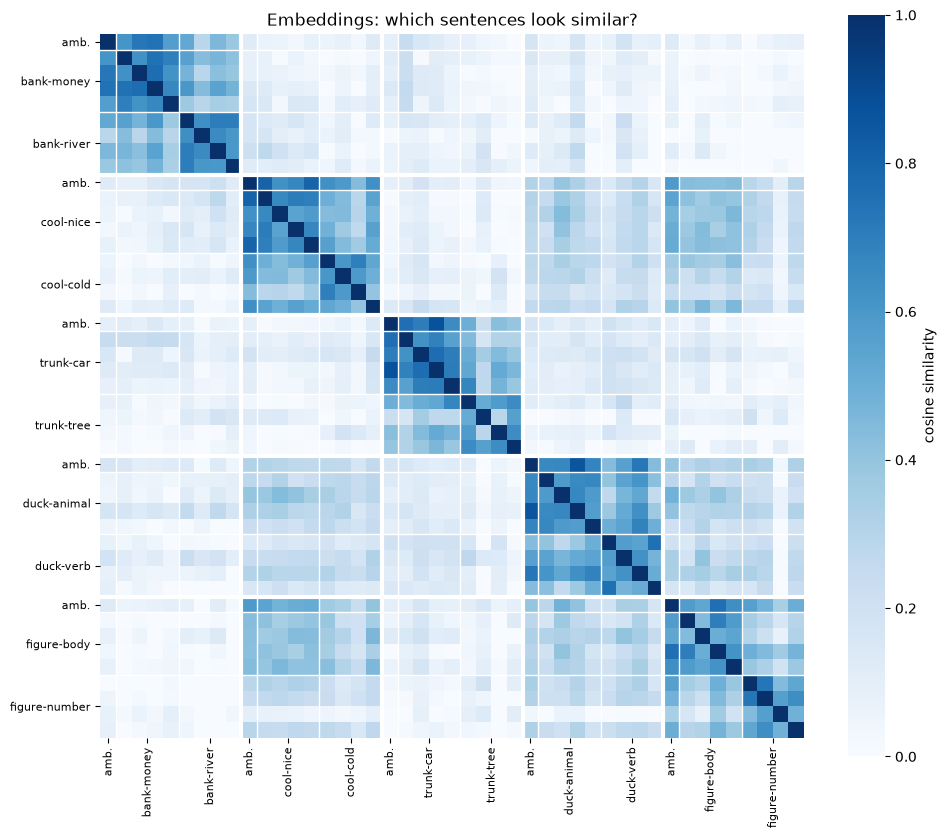

In [17]:
# --- Similarity heatmap for embeddings ---
sim_emb = cosine_similarity(embeddings)             # similarity between every pair of sentences
plot_similarity(sim_emb, "Embeddings: which sentences look similar?")

Compare this heatmap with the bag-of-words one above:

- ✅ **Within each word block, the two senses are more clearly separated.** For example, in the *bank* block, money-money pairs and river-river pairs are darker than money-river pairs. 
- ✅ **Same meaning now results in higher similarity, even when different words are used.** For example, the *cool-nice* block is now dark. Even through the sentences share almost no words, the model rates them as similar because they mean similar things. 
- ✅ **The whole map now carries information.** Every pair of sentences gets a similarity score that reflects how related they are, whether or not they share words. Whereas bag of words left most of the map blank, the embedding model relates all 45 sentences to each other, as best it can. 

> 💡 The exact similarity values depend on the model. Every embedding model organises its meaning space differently, based on its architecture and training data. A similarity of 0.6 from one model is not comparable to 0.6 from another. Only compare similarities within the same model.

### The map view

The heatmap shows similarity as numbers. We can also visualise the space directly. Below we make one small plot per ambiguous word. Each plot takes that word's nine sentences and compresses their 384-dimensional embeddings down to 2 dimensions so that they can make sense to our human eyes. (This compression is **PCA** — tomorrow morning we'll go into it further.) Distances on the plot approximate distances in the full space.

In [ ]:
# --- One small map per ambiguous word ---
fig, axes = plt.subplots(1, 5, figsize=(16, 4.2))

for ax, word in zip(axes, ["bank", "cool", "trunk", "duck", "figure"]):
    word_df = df[df["word"] == word]                 # the nine sentences for this word
    word_emb = embeddings[word_df.index]             # and their embeddings

    # Compress 384 dimensions to 2 for plotting
    pca = PCA(n_components=2, random_state=SEED)
    coords = pca.fit_transform(word_emb)

    # Plot each sense in its own colour
    senses = [s for s in word_df["sense"].unique() if s != "ambiguous"]
    for sense, colour in zip(senses, ["tab:blue", "tab:orange"]):
        idx = np.where(word_df["sense"].values == sense)[0]
        ax.scatter(coords[idx, 0], coords[idx, 1], color=colour, s=90,
                   alpha=0.85, edgecolor="white", linewidth=0.8, label=sense)

    # Plot the ambiguous sentence as a black star, and quote it under the title
    idx = np.where(word_df["sense"].values == "ambiguous")[0]
    ax.scatter(coords[idx, 0], coords[idx, 1], color="black", marker="*",
               s=380, edgecolor="white", linewidth=0.8, zorder=3, label="ambiguous")
    ambiguous_sentence = word_df[word_df["sense"] == "ambiguous"]["sentence"].iloc[0]

    ax.set_title(f"{word}\n" + r"$\bf{★}$" + f' "{ambiguous_sentence}"', fontsize=10)
    ax.legend(fontsize=8, frameon=False, loc="best")
    ax.set_xticks([]); ax.set_yticks([])             # only relative positions matter
    for spine in ax.spines.values():                 # light grey frame
        spine.set_color("lightgrey")

fig.suptitle("Each word's sentences in meaning space (2D view)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In each panel, the two senses sit in different regions — the model was able to separate them using sentence context.

The **black star** is the ambiguous sentence (e.g. "I saw her duck"). It has no disambiguating context, so the model had to place it somewhere based on its best guess. Check each panel: do you agree with where the model put the ambiguous sentence?

---

## 5. ⚖️ The verdict

Let's put numbers on our two test cases. For each pair of sentences, we compare the bag-of-words similarity with the embedding similarity. Remember not to compare values across the models, only within them. 

In [ ]:
# --- Score the two test cases ---
def compare(index_a, index_b):
    """Return the bag-of-words and embedding similarity between two sentences."""
    bow = cosine_similarity(X_bow[index_a], X_bow[index_b])[0, 0]
    emb = cosine_similarity(embeddings[[index_a]], embeddings[[index_b]])[0, 0]
    return bow, emb

# Test 1: same meaning, different words
a1 = df.index[df["sentence"] == "Her job is really interesting and fun."][0]
b1 = df.index[df["sentence"] == "She works in a creative field and loves it."][0]

# Test 2: same word, different meaning
a2 = df.index[df["sentence"] == "I'm heading to the bank to withdraw some cash."][0]
b2 = df.index[df["sentence"] == "I enjoy walking along the river bank."][0]

bow1, emb1 = compare(a1, b1)
bow2, emb2 = compare(a2, b2)

pd.DataFrame({
    "test": ["1: same meaning, different words", "2: same word, different meaning"],
    "bag of words": [round(bow1, 2), round(bow2, 2)],
    "embeddings": [round(emb1, 2), round(emb2, 2)],
})

Bag of words gives the paraphrases zero similarity (no shared words) and rates the opposite-sense pair higher (they share "bank"). The embeddings perform much better: the paraphrases score higher than the opposite-sense pair.

Here is the full picture:

| Representation | A text becomes... | Good choice when... | Cannot see... |
|---|---|---|---|
| Dictionary | counts of words from *your* list | the concept has a stable, unambiguous vocabulary | anything not on the list; word senses |
| Bag of words | counts of *every* word | words themselves are the signal; you need transparency and speed | meaning shared across different words; word senses |
| Embeddings | coordinates in a meaning space | meaning matters; paraphrase and context are important | little — but the numbers are not human-readable, and results depend on what the model was trained on |

💡 Generally, embeddings are the standard choice for contemporary NLP. However, there are sometimes cases (such as in Supervised Machine Learning) where a bag-of-words model will perform similarly well, and is just so much faster to compute, not to mention being more transparent / explainable. Embeddings are fairly magic, but they add a lot of opacity, and introduce significant complexity in terms of model and parameter choice (we will discuss this repeatedly in coming days).

---

## 6. ✏️ Your turn

**Exercise 1.** Write two sentences that mean the same thing but share no words. Compute their bag-of-words and embedding similarity and check whether the pattern from the table above holds.

```python
my_a = "..."   # your first sentence
my_b = "..."   # your second sentence
```

**Exercise 2.** Build your own **dictionary** for the *figure* sentences: one word list for the body sense, one for the number sense. Apply them with the `count_hits()` function from section 2. How many of the eight sentences does your dictionary classify correctly? Which ones fool it, and why?

**Exercise 3 (advanced).** Combine the preprocessing steps into one reusable function: `preprocess(sentence)` should lowercase, tokenize, remove stopwords, and stem, then return the cleaned sentence as a string. Test it on a few corpus sentences. (Every serious text analysis project has a function like this.)

**Exercise 4 (if you have time).** Add a sixth ambiguous word to the corpus. English has plenty: *match*, *bat*, *spring*, *pitch*. Write one ambiguous sentence and four sentences per sense, add them to `corpus_data`, and re-run the notebook from the top. Do the heatmaps and map behave the way you expect?

In [ ]:
# your code here (Exercises 1, 2 and 3)


---
### Solution — Exercise 1

*Try it yourself before looking!*

In [ ]:
# --- Exercise 1 solution ---
my_a = "The government passed a new law."
my_b = "Parliament approved fresh legislation."

# Bag of words: stem the sentences and transform with the fitted vectoriser
bow_a = vec_final.transform([stem_sentence(my_a)])
bow_b = vec_final.transform([stem_sentence(my_b)])
bow_sim = cosine_similarity(bow_a, bow_b)[0, 0]

# Embeddings: encode both sentences with the same model
emb_pair = embedding_model.encode([my_a, my_b])
emb_sim = cosine_similarity(emb_pair[[0]], emb_pair[[1]])[0, 0]

print(f"Bag-of-words similarity: {bow_sim:.2f}")
print(f"Embedding similarity:    {emb_sim:.2f}")

### Solution — Exercise 2

In [ ]:
# --- Exercise 2 solution: a dictionary for the two figure senses ---
body_words = ["body", "shape", "grace", "dress", "attractive", "flattering"]
number_words = ["numerical", "calculations", "data", "quoted", "accurate"]

figure_df = df[(df["word"] == "figure") & (df["sense"] != "ambiguous")].copy()
figure_df["body_hits"] = [count_hits(s, body_words) for s in figure_df["sentence"]]
figure_df["number_hits"] = [count_hits(s, number_words) for s in figure_df["sentence"]]

figure_df[["sense", "sentence", "body_hits", "number_hits"]]

Every sentence scores on the intended list — with a carefully written word list, a dictionary works. But notice how much work the word lists took, for eight sentences we could read ourselves — and a sentence like "She carries herself with grace and confidence." only scores because we happened to put *grace* on the list. That is the dictionary trade-off from section 2 again: you get out what you put in.

### Solution — Exercise 3

In [ ]:
# --- Exercise 3 solution: one reusable preprocessing function ---
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS   # the stopword list the vectorizer uses

def preprocess(sentence):
    """Lowercase, tokenize, remove stopwords, and stem one sentence."""
    tokens = TreebankWordTokenizer().tokenize(sentence.lower())   # lowercase + tokenize
    tokens = [t for t in tokens if t.isalpha()]                   # drop punctuation tokens
    tokens = [t for t in tokens if t not in ENGLISH_STOP_WORDS]   # remove stopwords
    stems = [stemmer.stem(t) for t in tokens]                     # stem what is left
    return " ".join(stems)

# Test it on a few corpus sentences
for s in df["sentence"][:3]:
    print(f"{s:<50} ->  {preprocess(s)}")

> 💡 Try replacing the stemmer with a **lemmatizer** (NLTK's `WordNetLemmatizer` or the `spaCy` library) for proper dictionary forms, and adjust the stopword list to your domain (you can pass your own list rather than using a premade).

No shared words, so bag of words gives 0. The embedding model recognises that both sentences describe the same event.

---

## 🔮 Looking ahead

Tomorrow we put representations to work for Unsupervised Machine Learning (UML). In the morning you will cluster documents using (TF-IDF weighted) bags of words, and see how far weighted word counts get you. In the afternoon we switch to embeddings and BERTopic, and see the difference the representation makes. Day 3 will then repeat this for Supervised Machine Learning (SML),